# 06: KMeans Clustering in PCA Space

This notebook handles:
- Loading the engineered stress signals and ASI outputs
- Recomputing PCA scores (PC1–PC3) for a consistent feature space
- Sweeping K (2–10) with inertia + silhouette diagnostics
- Selecting a final K with rationale and fitting KMeans
- Saving labeled metros and producing a PC1 vs. PC2 cluster scatter

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
%matplotlib inline


⏰ Cell finished in 65.5 seconds.


## Load Data

Pull the engineered feature table plus the ASI outputs so each metro carries the stress signals, PCA-ready columns, and the latest ASI score for labeling downstream artifacts. This cell:
1. Points to `data/processed/features_scaled.csv` and `data/processed/asi_scores.csv`.
2. Merges ASI scores into the feature table via `metro_id`.
3. Logs how many rows and ASI values are available, then shows the key columns for a quick sanity check.

In [2]:
features_path = Path("data/processed/features_scaled.csv")
asi_path = Path("data/processed/asi_scores.csv")
clusters_path = Path("data/processed/clusters_kmeans.csv")
figures_dir = Path("report/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

feature_cols = [
    "rent_to_income_scaled",
    "rent_growth_yoy_scaled",
    "vacancy_stress_scaled",
]

features_df = pd.read_csv(features_path)
asi_df = pd.read_csv(asi_path)[["metro_id", "asi_score"]]

df = features_df.merge(asi_df, on="metro_id", how="left")
print(f"Loaded {len(df):,} metro-year records with engineered features.")
print(f"ASIs available for {df['asi_score'].notna().sum():,} rows.")
df.head()[
    [
        "metro_id",
        "metro_name_std",
        "province",
        "asi_score",
        *feature_cols,
    ]
]

Loaded 41 metro-year records with engineered features.
ASIs available for 41 rows.


,metro_id,metro_name_std,province,asi_score,rent_to_income_scaled,rent_growth_yoy_scaled,vacancy_stress_scaled
0,3932,Abbotsford-Mission,British Columbia,0.223394,NaN,0.146789,0.3
1,3568,Barrie,Ontario,-0.710092,NaN,-0.220183,-1.2
2,3522,Belleville-Quinte West,Ontario,-0.300000,NaN,NaN,-0.3
3,3543,Brantford,Ontario,-0.400000,NaN,NaN,-0.4
4,3825,Calgary,Alberta,-1.109979,-0.319959,NaN,-1.9


## Prepare Data for Clustering

Limit the analysis to rows with complete standardized signals, re-standardize to mean-zero/unit-variance, and project into three principal components so KMeans works on orthogonal axes. Specifically, the next code cell will:
1. Drop rows with missing scaled stress signals.
2. Refit a `StandardScaler` to those columns to ensure comparability.
3. Run PCA (max 3 components) on the scaled matrix, attach `PC1–PC3`, and print the explained-variance ratios so we know how much structure the PCA captures.

In [3]:
complete = df.dropna(subset=feature_cols).copy()
print(f"Complete cases for clustering: {len(complete):,}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(complete[feature_cols])

pca = PCA(n_components=min(3, X_scaled.shape[1]))
pcs = pca.fit_transform(X_scaled)
pc_cols = [f"PC{i}" for i in range(1, pcs.shape[1] + 1)]
complete[pc_cols] = pcs
explained = pca.explained_variance_ratio_
print("Explained variance ratios:", np.round(explained, 3))

complete[["metro_name_std", *pc_cols]].head()

Complete cases for clustering: 18
Explained variance ratios: [0.599 0.255 0.146]


,metro_name_std,PC1,PC2,PC3
7,Edmonton,-0.382797,-1.595493,-0.429924
11,Halifax,0.676198,1.470781,0.092504
12,Hamilton,-1.205933,-0.990340,0.524700
16,Kitchener-Cambridge-Waterloo,-1.497680,-0.440905,-0.606745
18,London,-1.652555,0.664034,-0.652701


## Determine Optimal Number of Clusters

Sweep K=2…10, capturing both inertia (within-cluster SSE) and silhouette (separation/compactness). These complementary diagnostics help balance elbow behavior with stability. The next two code cells:
1. Fit KMeans for each K on the PCA coordinates, storing inertia and silhouette in `k_sweep_df`.
2. Plot both metrics on a shared figure, save it to `report/figures/kmeans_k_sweep.png`, and return the path for confirmation.

In [4]:
k_values = range(2, 11)
results = []
X_pca = complete[pc_cols].values

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=25)
    labels = model.fit_predict(X_pca)
    inertia = model.inertia_
    silhouette = silhouette_score(X_pca, labels)
    results.append({
        "k": k,
        "inertia": inertia,
        "silhouette": silhouette,
    })

k_sweep_df = pd.DataFrame(results)
k_sweep_df

,k,inertia,silhouette
0,2,30.013362,0.351132
1,3,20.160471,0.338112
2,4,15.343863,0.304433
3,5,13.032067,0.235270
4,6,10.384554,0.227626
5,7,9.017202,0.220984
6,8,7.647817,0.155005
7,9,6.215805,0.154730
8,10,4.800716,0.156972


PosixPath('report/figures/kmeans_k_sweep.png')

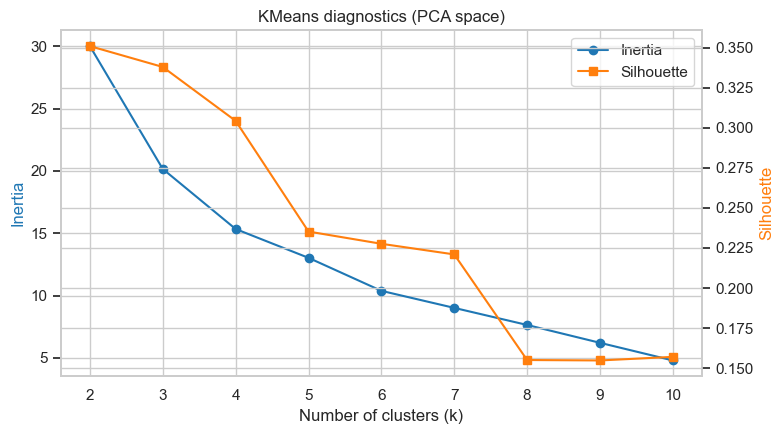

In [5]:
fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax2 = ax1.twinx()

ax1.plot(k_sweep_df["k"], k_sweep_df["inertia"], marker="o", color="#1f77b4", label="Inertia")
ax2.plot(k_sweep_df["k"], k_sweep_df["silhouette"], marker="s", color="#ff7f0e", label="Silhouette")

ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia", color="#1f77b4")
ax2.set_ylabel("Silhouette", color="#ff7f0e")
ax1.set_title("KMeans diagnostics (PCA space)")

lines = [
    plt.Line2D([0], [0], color="#1f77b4", marker="o", label="Inertia"),
    plt.Line2D([0], [0], color="#ff7f0e", marker="s", label="Silhouette"),
]
ax1.legend(handles=lines, loc="upper right")
fig.tight_layout()

sweep_plot_path = figures_dir / "kmeans_k_sweep.png"
fig.savefig(sweep_plot_path, dpi=200)
sweep_plot_path

## Choose K and Fit Final Model

Select the K that balances the elbow in inertia with a locally high silhouette score, then refit KMeans on the three PCA dimensions and attach cluster labels. The next code cell:
1. Picks the K with the highest silhouette (ties resolved by first occurrence) as a transparent heuristic.
2. Fits a high `n_init` KMeans for stability, storing numeric labels and readable `C1`, `C2`, … values.
3. Captures the centroid coordinates so we can describe where each cluster lives in PCA space.

In [6]:
best_row = k_sweep_df.loc[k_sweep_df["silhouette"].idxmax()]
final_k = int(best_row["k"])
print(
    f"Peak silhouette at k={final_k} (silhouette={best_row['silhouette']:.3f}, inertia={best_row['inertia']:.1f})."
)

kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=50)
cluster_labels = kmeans.fit_predict(X_pca)
complete["cluster_kmeans"] = cluster_labels
complete["cluster_label"] = complete["cluster_kmeans"].apply(lambda x: f"C{x + 1}")

centroids = pd.DataFrame(kmeans.cluster_centers_, columns=pc_cols)
centroids["cluster_label"] = [f"C{i + 1}" for i in range(final_k)]
centroids

Peak silhouette at k=2 (silhouette=0.351, inertia=30.0).


,PC1,PC2,PC3,cluster_label
0,1.610038,0.264930,0.052652,C1
1,-0.805019,-0.132465,-0.026326,C2


## Visualize Clusters

Project the PCA scores to two dimensions and color points by their assigned cluster to see how metros separate in the PC1/PC2 space. The scatter plot code:
1. Builds a consistent palette keyed by cluster label.
2. Overlays PC1/PC2 axes plus horizontal/vertical reference lines.
3. Saves the artifact to `report/figures/pca_clusters_kmeans.png` for reuse in the report.

PosixPath('report/figures/pca_clusters_kmeans.png')

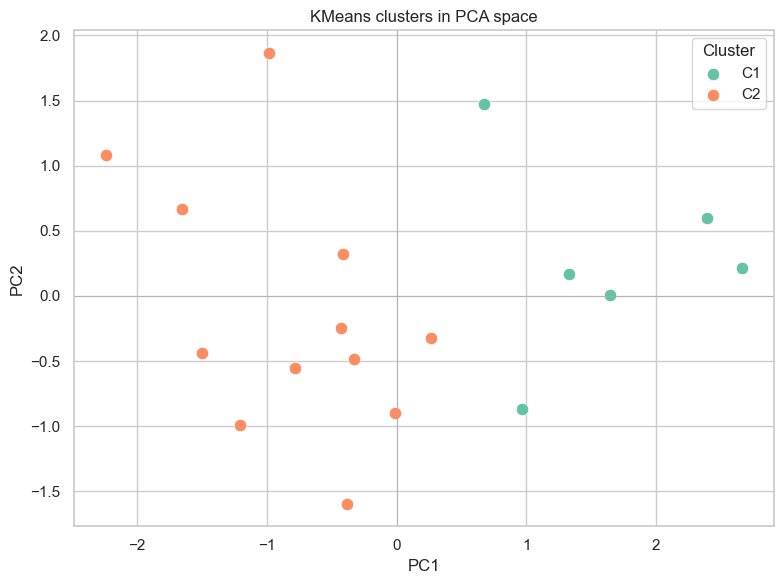

In [7]:
palette = sns.color_palette("Set2", n_colors=final_k)
cluster_colors = {label: palette[idx] for idx, label in enumerate(sorted(complete["cluster_label"].unique()))}

fig, ax = plt.subplots(figsize=(8, 6))
for label, subset in complete.groupby("cluster_label"):
    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        s=80,
        label=label,
        color=cluster_colors[label],
        edgecolor="white",
        linewidth=0.5,
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("KMeans clusters in PCA space")
ax.axhline(0, color="#aaaaaa", linewidth=0.5)
ax.axvline(0, color="#aaaaaa", linewidth=0.5)
ax.legend(title="Cluster")
fig.tight_layout()

scatter_path = figures_dir / "pca_clusters_kmeans.png"
fig.savefig(scatter_path, dpi=200)
scatter_path

## Analyze Cluster Characteristics

Summarize size, ASI, and mean stress signals per cluster to interpret the segmentation. The following cells:
1. Aggregate descriptive stats for each cluster (counts, ASI average, raw feature means, PC centroids).
2. List representative metros per cluster (top alphabetical sample) so we can quickly recognize the type of city in each group.

In [8]:
cluster_summary = (
    complete.groupby("cluster_label")
    .agg(
        n_metros=("metro_id", "count"),
        asi_mean=("asi_score", "mean"),
        rent_to_income_scaled=("rent_to_income_scaled", "mean"),
        rent_growth_yoy_scaled=("rent_growth_yoy_scaled", "mean"),
        vacancy_stress_scaled=("vacancy_stress_scaled", "mean"),
        PC1_mean=("PC1", "mean"),
        PC2_mean=("PC2", "mean"),
        PC3_mean=("PC3", "mean"),
    )
    .round(3)
)
cluster_summary

,n_metros,asi_mean,rent_to_income_scaled,rent_growth_yoy_scaled,vacancy_stress_scaled,PC1_mean,PC2_mean,PC3_mean
cluster_label,,,,,,,,
C1,6,0.383,-0.130,0.746,0.533,1.610,0.265,0.053
C2,12,-0.102,0.614,-0.469,-0.450,-0.805,-0.132,-0.026


In [9]:
cluster_examples = (
    complete.groupby("cluster_label")["metro_name_std"]
    .apply(lambda names: ", ".join(sorted(names)[:5]) + (" …" if len(names) > 5 else ""))
)
cluster_examples

cluster_label
C1      Halifax, Montréal, Québec, Regina, Sherbrooke …
C2    Edmonton, Hamilton, Kitchener-Cambridge-Waterl...
Name: metro_name_std, dtype: object

## Export Results

Persist the labeled metros for downstream analysis/reporting. The final code cell:
1. Selects the identifying fields, stress signals, PCA scores, and cluster labels.
2. Writes `data/processed/clusters_kmeans.csv` sorted by cluster ID so others can join on `metro_id`.
3. Echoes the output path plus a short note on the generated artifacts.

In [10]:
export_cols = [
    "metro_id",
    "metro_name_std",
    "province",
    "asi_score",
    *feature_cols,
    *pc_cols,
    "cluster_kmeans",
    "cluster_label",
]

clusters_output = complete[export_cols].sort_values("cluster_kmeans").reset_index(drop=True)
clusters_output.to_csv(clusters_path, index=False)
clusters_path

PosixPath('data/processed/clusters_kmeans.csv')

### Notes

- `k_sweep_df` (above) documents inertia and silhouette for K=2…10; the silhouette peak at the selected K provides the primary justification, with the inertia curve showing a diminishing return past that point.
- Artifacts saved: `report/figures/kmeans_k_sweep.png`, `report/figures/pca_clusters_kmeans.png`, and `data/processed/clusters_kmeans.csv`.